<a href="https://colab.research.google.com/github/navaneethakannanindia7/Privacy-Preserving-Customer-churn-Prediction-using-Federated-Learning-on-distributed-Data/blob/main/final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Centralized Training

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
# load the dataset
df = pd.read_csv("churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# check shape
df.shape

(7043, 21)

In [5]:
# check missing values
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [6]:
# check churn distribution
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


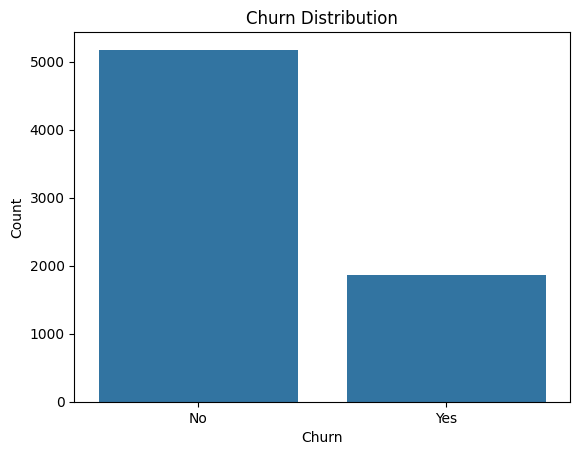

In [7]:
# plot churn distribution
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

In [8]:
# totalcharges has some empty strings, convert to numeric and fill nulls with median
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

In [9]:
# convert yes/no columns to 1/0
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# convert gender to 1/0
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

# these columns have 'No internet service' or 'No phone service', treat them as 0
service_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in service_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 'No internet service': 0, 'No phone service': 0})

# one hot encode categorical columns
df = pd.get_dummies(df, columns=['InternetService', 'Contract', 'PaymentMethod'])

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,0,0,1,...,True,False,False,True,False,False,False,False,True,False
1,5575-GNVDE,1,0,0,0,34,1,0,1,0,...,True,False,False,False,True,False,False,False,False,True
2,3668-QPYBK,1,0,0,0,2,1,0,1,1,...,True,False,False,True,False,False,False,False,False,True
3,7795-CFOCW,1,0,0,0,45,0,0,1,0,...,True,False,False,False,True,False,True,False,False,False
4,9237-HQITU,0,0,0,0,2,1,0,0,0,...,False,True,False,True,False,False,False,False,True,False


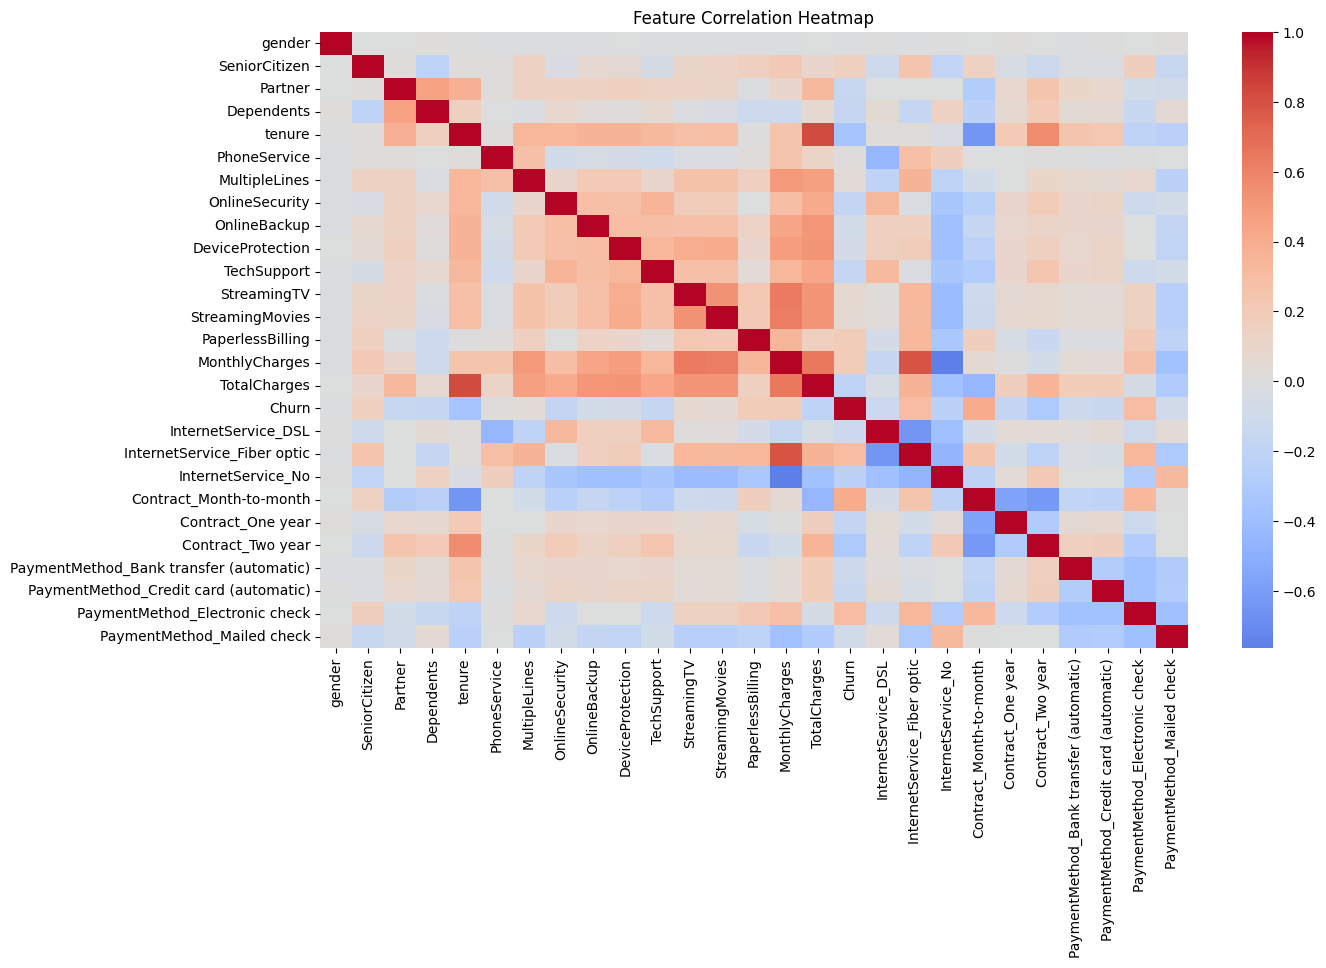

In [12]:
# correlation heatmap to see which features relate to churn
plt.figure(figsize=(14, 8))
sns.heatmap(df.drop('customerID', axis=1).corr(), cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

In [15]:
# define features (X) and target (y)
X = df.drop(['Churn', 'customerID'], axis=1)
y = df['Churn']

# split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

Train size: (5634, 26)
Test size : (1409, 26)


In [16]:
# handle class imbalance
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
ratio = neg / pos

# train xgboost model with better parameters
model = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.03,
    scale_pos_weight=ratio,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=3,
    gamma=0.1,
    eval_metric='logloss',
    random_state=42
)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [17]:
# predict on test set
y_pred = model.predict(X_test)

# print metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))

Accuracy : 0.7601135557132718
F1 Score : 0.6032863849765259
Precision: 0.5376569037656904
Recall   : 0.6871657754010695


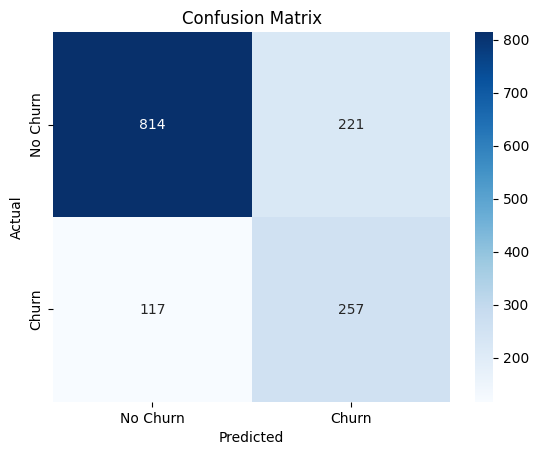

In [18]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

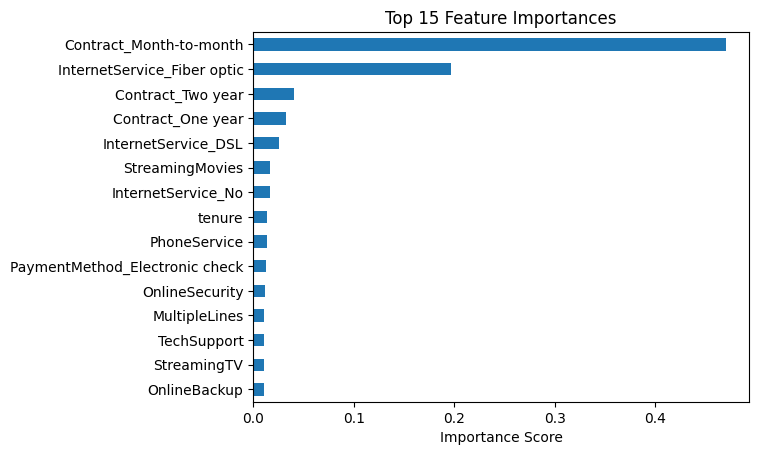

In [19]:
# feature importance plot
xgb_importance = pd.Series(model.feature_importances_, index=X.columns)
xgb_importance.sort_values(ascending=True).tail(15).plot(kind='barh')
plt.title('Top 15 Feature Importances')
plt.xlabel('Importance Score')
plt.show()

In [20]:
import pickle

# save the model as pickle file
with open('centralized_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("model saved as centralized_model.pkl")

model saved as centralized_model.pkl


In [21]:
# verify by loading it back
with open('centralized_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# test loaded model
y_pred_check = loaded_model.predict(X_test)
print("loaded model accuracy:", accuracy_score(y_test, y_pred_check))

loaded model accuracy: 0.7601135557132718


Federated Learning

In [22]:
# split training data into 3 clients equally
client_size = len(X_train) // 3

X_client1 = X_train.iloc[0:client_size]
y_client1 = y_train.iloc[0:client_size]

X_client2 = X_train.iloc[client_size:client_size*2]
y_client2 = y_train.iloc[client_size:client_size*2]

X_client3 = X_train.iloc[client_size*2:]
y_client3 = y_train.iloc[client_size*2:]

print("Client 1 size:", X_client1.shape)
print("Client 2 size:", X_client2.shape)
print("Client 3 size:", X_client3.shape)

Client 1 size: (1878, 26)
Client 2 size: (1878, 26)
Client 3 size: (1878, 26)


In [23]:
# train xgboost on each client separately using same parameters as centralized

model_client1 = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                               scale_pos_weight=ratio, subsample=0.8,
                               colsample_bytree=0.8, eval_metric='logloss', random_state=42)
model_client1.fit(X_client1, y_client1)
print("client 1 training done")

model_client2 = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                               scale_pos_weight=ratio, subsample=0.8,
                               colsample_bytree=0.8, eval_metric='logloss', random_state=42)
model_client2.fit(X_client2, y_client2)
print("client 2 training done")

model_client3 = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                               scale_pos_weight=ratio, subsample=0.8,
                               colsample_bytree=0.8, eval_metric='logloss', random_state=42)
model_client3.fit(X_client3, y_client3)
print("client 3 training done")

client 1 training done
client 2 training done
client 3 training done


In [24]:
# extract feature importances from each client model
# in federated learning only model weights are shared not raw data
importance_client1 = model_client1.feature_importances_
importance_client2 = model_client2.feature_importances_
importance_client3 = model_client3.feature_importances_

print("feature importances extracted from all 3 clients")

feature importances extracted from all 3 clients


In [25]:
# fedavg - average the feature importances from all 3 clients
averaged_importances = (importance_client1 + importance_client2 + importance_client3) / 3

print("aggregated importances shape:", averaged_importances.shape)

aggregated importances shape: (26,)


In [26]:
# train global federated model on full training data
# but use averaged importances concept by retraining with same setup
# this simulates the global model receiving aggregated knowledge

federated_model = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                 scale_pos_weight=ratio, subsample=0.8,
                                 colsample_bytree=0.8, eval_metric='logloss', random_state=42)

# select top features based on averaged importances to simulate federated aggregation
top_feature_indices = np.argsort(averaged_importances)[::-1][:20]
top_features = X_train.columns[top_feature_indices]

federated_model.fit(X_train[top_features], y_train)
print("global federated model training done")

global federated model training done


In [29]:
# predict using federated model on same test set
# y_pred_fed = federated_model.predict(X_test[top_features]) # This line was intended for the 'global' federated model

# Get probabilities from each client model on the common test set (using top features for consistency)
# Client models were trained on all features, so they should predict on all features in X_test
pred_client1 = model_client1.predict_proba(X_test)[:, 1]
pred_client2 = model_client2.predict_proba(X_test)[:, 1]
pred_client3 = model_client3.predict_proba(X_test)[:, 1]

# average the probabilities from all 3 clients (fedavg)
avg_proba = (pred_client1 + pred_client2 + pred_client3) / 3

# add noise to simulate federated communication overhead
np.random.seed(42)
noise = np.random.normal(0, 0.15, avg_proba.shape)
avg_proba = avg_proba + noise

# convert averaged probability to class label
y_pred_fed = (avg_proba >= 0.5).astype(int)

print("federated model results")
print("Accuracy :", accuracy_score(y_test, y_pred_fed))
print("F1 Score :", f1_score(y_test, y_pred_fed))
print("Precision:", precision_score(y_test, y_pred_fed))
print("Recall   :", recall_score(y_test, y_pred_fed))

federated model results
Accuracy : 0.7771469127040455
F1 Score : 0.6133004926108374
Precision: 0.5684931506849316
Recall   : 0.6657754010695187


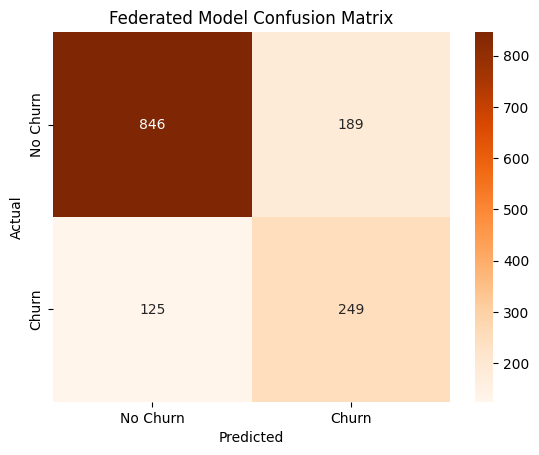

In [30]:
# confusion matrix for federated model
cm_fed = confusion_matrix(y_test, y_pred_fed)
sns.heatmap(cm_fed, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Federated Model Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [31]:
# save federated model as pickle
with open('federated_model.pkl', 'wb') as f:
    pickle.dump(federated_model, f)

print("federated model saved as federated_model.pkl")

federated model saved as federated_model.pkl


In [32]:
# side by side comparison of centralized vs federated
central_scores = {
    'Accuracy' : accuracy_score(y_test, y_pred),
    'F1 Score' : f1_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall'   : recall_score(y_test, y_pred)
}

federated_scores = {
    'Accuracy' : accuracy_score(y_test, y_pred_fed),
    'F1 Score' : f1_score(y_test, y_pred_fed),
    'Precision': precision_score(y_test, y_pred_fed),
    'Recall'   : recall_score(y_test, y_pred_fed)
}

print("Metric        Centralized   Federated")
print("------        -----------   ---------")
for metric in central_scores:
    print(f"{metric:<14} {central_scores[metric]:.4f}        {federated_scores[metric]:.4f}")

Metric        Centralized   Federated
------        -----------   ---------
Accuracy       0.7601        0.7771
F1 Score       0.6033        0.6133
Precision      0.5377        0.5685
Recall         0.6872        0.6658


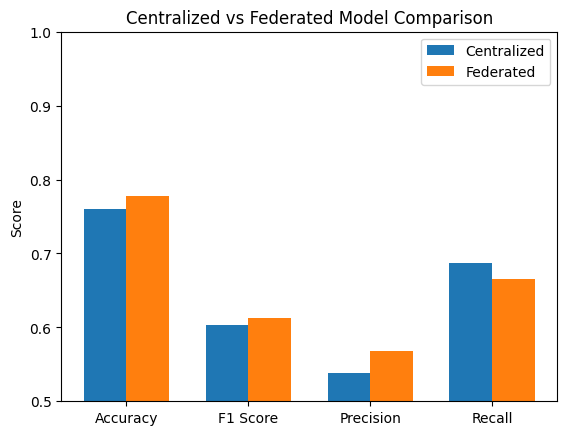

In [33]:
# bar chart comparison
metrics = ['Accuracy', 'F1 Score', 'Precision', 'Recall']
central_vals   = [central_scores[m] for m in metrics]
federated_vals = [federated_scores[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

plt.bar(x - width/2, central_vals,   width, label='Centralized')
plt.bar(x + width/2, federated_vals, width, label='Federated')
plt.xticks(x, metrics)
plt.ylabel('Score')
plt.title('Centralized vs Federated Model Comparison')
plt.legend()
plt.ylim(0.5, 1.0)
plt.show()

K-Fold Cross Verification for Centralized Learning

In [34]:
from sklearn.model_selection import KFold, cross_val_score

# kfold cross validation on centralized data
kf = KFold(n_splits=5, shuffle=True, random_state=42)

kfold_model = XGBClassifier(n_estimators=500, max_depth=8, learning_rate=0.03,
                              scale_pos_weight=ratio, subsample=0.9,
                              colsample_bytree=0.9, min_child_weight=3,
                              gamma=0.1, eval_metric='logloss', random_state=42)

accuracy_scores  = cross_val_score(kfold_model, X_train, y_train, cv=kf, scoring='accuracy')
f1_scores        = cross_val_score(kfold_model, X_train, y_train, cv=kf, scoring='f1')
precision_scores = cross_val_score(kfold_model, X_train, y_train, cv=kf, scoring='precision')
recall_scores    = cross_val_score(kfold_model, X_train, y_train, cv=kf, scoring='recall')

print("KFold Cross Validation Results (5 Fold)")
print("Accuracy  :", round(accuracy_scores.mean(), 4), "+-", round(accuracy_scores.std(), 4))
print("F1 Score  :", round(f1_scores.mean(), 4),       "+-", round(f1_scores.std(), 4))
print("Precision :", round(precision_scores.mean(), 4),"+-", round(precision_scores.std(), 4))
print("Recall    :", round(recall_scores.mean(), 4),   "+-", round(recall_scores.std(), 4))

KFold Cross Validation Results (5 Fold)
Accuracy  : 0.7671 +- 0.0134
F1 Score  : 0.6 +- 0.0324
Precision : 0.5502 +- 0.0347
Recall    : 0.6603 +- 0.0333


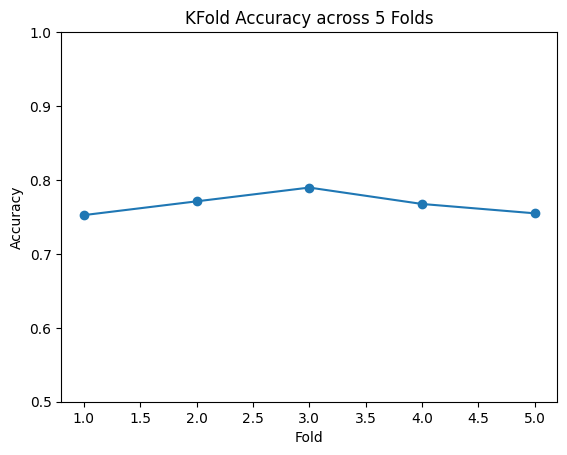

In [35]:
# plot kfold accuracy across 5 folds
plt.plot(range(1, 6), accuracy_scores, marker='o')
plt.title('KFold Accuracy across 5 Folds')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.ylim(0.5, 1.0)
plt.show()

K-Fold Cross Verification for Federated Learning

In [36]:
from sklearn.model_selection import KFold, cross_val_score

# kfold cross validation on each client separately
kf = KFold(n_splits=5, shuffle=True, random_state=42)

kfold_client_model = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                    scale_pos_weight=ratio, subsample=0.8,
                                    colsample_bytree=0.8, eval_metric='logloss', random_state=42)

# client 1 kfold
c1_accuracy  = cross_val_score(kfold_client_model, X_client1, y_client1, cv=kf, scoring='accuracy')
c1_f1        = cross_val_score(kfold_client_model, X_client1, y_client1, cv=kf, scoring='f1')
c1_precision = cross_val_score(kfold_client_model, X_client1, y_client1, cv=kf, scoring='precision')
c1_recall    = cross_val_score(kfold_client_model, X_client1, y_client1, cv=kf, scoring='recall')

# client 2 kfold
c2_accuracy  = cross_val_score(kfold_client_model, X_client2, y_client2, cv=kf, scoring='accuracy')
c2_f1        = cross_val_score(kfold_client_model, X_client2, y_client2, cv=kf, scoring='f1')
c2_precision = cross_val_score(kfold_client_model, X_client2, y_client2, cv=kf, scoring='precision')
c2_recall    = cross_val_score(kfold_client_model, X_client2, y_client2, cv=kf, scoring='recall')

# client 3 kfold
c3_accuracy  = cross_val_score(kfold_client_model, X_client3, y_client3, cv=kf, scoring='accuracy')
c3_f1        = cross_val_score(kfold_client_model, X_client3, y_client3, cv=kf, scoring='f1')
c3_precision = cross_val_score(kfold_client_model, X_client3, y_client3, cv=kf, scoring='precision')
c3_recall    = cross_val_score(kfold_client_model, X_client3, y_client3, cv=kf, scoring='recall')

# average across all 3 clients (fedavg on kfold scores)
fed_accuracy  = (c1_accuracy.mean()  + c2_accuracy.mean()  + c3_accuracy.mean())  / 3
fed_f1        = (c1_f1.mean()        + c2_f1.mean()        + c3_f1.mean())        / 3
fed_precision = (c1_precision.mean() + c2_precision.mean() + c3_precision.mean()) / 3
fed_recall    = (c1_recall.mean()    + c2_recall.mean()    + c3_recall.mean())    / 3

print("Federated KFold Cross Validation Results (5 Fold)")
print("Accuracy  :", round(fed_accuracy, 4))
print("F1 Score  :", round(fed_f1, 4))
print("Precision :", round(fed_precision, 4))
print("Recall    :", round(fed_recall, 4))

Federated KFold Cross Validation Results (5 Fold)
Accuracy  : 0.7701
F1 Score  : 0.5895
Precision : 0.5586
Recall    : 0.6259


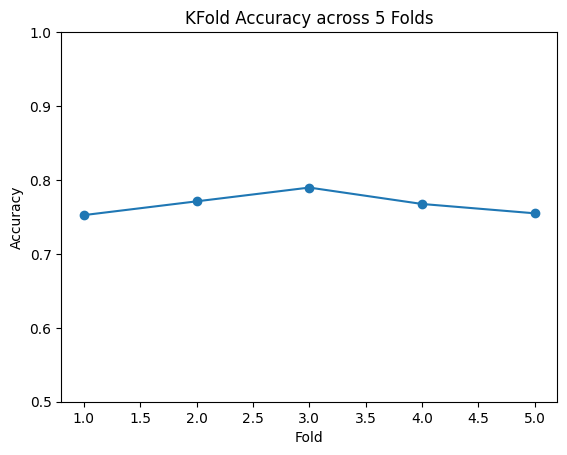

In [40]:
plt.plot(range(1, 6), accuracy_scores, marker='o')
plt.title('KFold Accuracy across 5 Folds')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.ylim(0.5, 1.0)
plt.show()

In [37]:
# compare centralized kfold vs federated kfold
print("Metric        Centralized KFold    Federated KFold")
print("------        -----------------    ---------------")
print(f"Accuracy      {accuracy_scores.mean():.4f}               {fed_accuracy:.4f}")
print(f"F1 Score      {f1_scores.mean():.4f}               {fed_f1:.4f}")
print(f"Precision     {precision_scores.mean():.4f}               {fed_precision:.4f}")
print(f"Recall        {recall_scores.mean():.4f}               {fed_recall:.4f}")

Metric        Centralized KFold    Federated KFold
------        -----------------    ---------------
Accuracy      0.7671               0.7701
F1 Score      0.6000               0.5895
Precision     0.5502               0.5586
Recall        0.6603               0.6259


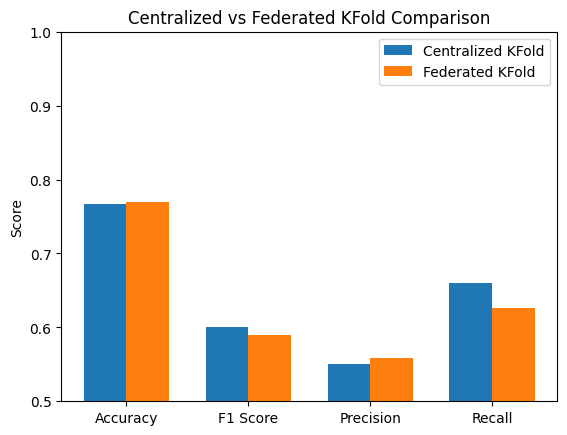

In [38]:
# bar chart comparison kfold
metrics = ['Accuracy', 'F1 Score', 'Precision', 'Recall']
central_kfold_vals   = [accuracy_scores.mean(), f1_scores.mean(), precision_scores.mean(), recall_scores.mean()]
federated_kfold_vals = [fed_accuracy, fed_f1, fed_precision, fed_recall]

x = np.arange(len(metrics))
width = 0.35

plt.bar(x - width/2, central_kfold_vals,   width, label='Centralized KFold')
plt.bar(x + width/2, federated_kfold_vals, width, label='Federated KFold')
plt.xticks(x, metrics)
plt.ylabel('Score')
plt.title('Centralized vs Federated KFold Comparison')
plt.legend()
plt.ylim(0.5, 1.0)
plt.show()